# Combined Student Survey: Data Preprocessing & Simple Linear Regression


### Notebook Sections:
1. **Data Load and Column Renaming**: Mapping Google Forms columns to clean handles.
2. **Data Preprocessing & Cleaning**: Standardizing expected package format, capping GPA anomalies, and median imputation.
3. **Train-Test Split**: Partitioning data 80% train and 20% test.
4. **Scikit-learn Simple Linear Regression**: Fitting the model to predict GPA from Package Expectations and calculating metrics.
5. **Manual OLS Derivation**: Computing regression parameters from scratch using NumPy formulas and verifying equivalence.
6. **Parameter Export & Visualization**: Exporting model coefficients and plotting actual vs. predicted values.
7. **Data Analyst Interpretations**: Justification of modeling and cleaning decisions.

## Section 1: Load CSV and Rename Columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

# Set plots aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

# 1. Load Raw CSV
raw_df = pd.read_csv('Student_Awareness_Survey__Responses__-_Form_Responses_1.csv')
print(f"Raw dataset shape: {raw_df.shape}")

# 2. Define short aliases mapping
rename_dict = {
    'Your GPA of last semester': 'gpa',
    'What are your package expectations (LPA)': 'package_exp',
    'Rate your technical competencies': 'tech_rating',
    'Your CIA % of last semester': 'cia_pct',
    'Your maximum attendance % till last semester': 'attendance_pct',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'min_sal',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'max_sal',
    'What is the median salary of students placed through campus (In LPA..respond as a number)': 'median_sal'
}

df = raw_df.rename(columns=rename_dict)
print("Renamed Columns:", [c for c in df.columns if c in rename_dict.values()])
df.head()

Raw dataset shape: (50, 15)
Renamed Columns: ['min_sal', 'max_sal', 'median_sal', 'tech_rating', 'package_exp', 'cia_pct', 'gpa', 'attendance_pct']


,Timestamp,Registration Number,Email,Job role that you are interested in,min_sal,max_sal,median_sal,Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,tech_rating,package_exp,cia_pct,gpa,attendance_pct,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


## Section 2: Data Preprocessing and Cleaning

We apply cleaning rules:
1. Parse the strings in `package_exp` and convert entries containing absolute Rupees into LPA by dividing by 100,000.
2. Impute missing values in `package_exp` using the median value of expectations.
3. Filter out academic GPA anomalies (GPAs > 5.0) which violate scale domains.

In [2]:
# Clean package_exp strings and values
def clean_package_expression(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().lower()
    # Extract digits and decimal point
    cleaned_str = ''.join([c for c in val_str if c.isdigit() or c == '.'])
    if not cleaned_str:
        return np.nan
    try:
        num = float(cleaned_str)
        # Scale absolute rupees entries
        if num >= 100000:
            num = num / 100000.0
        return num
    except ValueError:
        return np.nan

df['package_exp'] = df['package_exp'].apply(clean_package_expression)

# Median Imputation on expectations
median_package = df['package_exp'].median()
df['package_exp'] = df['package_exp'].fillna(median_package)
print(f"Imputed package expectations with median: {median_package} LPA")

# Cap/Drop GPA Outliers
print(f"Shape before dropping GPA anomaly: {df.shape}")
df = df[df['gpa'] <= 5]
print(f"Shape after dropping GPA anomaly: {df.shape}")

# Save cleaned dataset locally
df.to_csv('cleaned_survey.csv', index=False)

# Show Null Counts of target columns
cols = ['gpa', 'package_exp', 'tech_rating', 'cia_pct', 'attendance_pct']
print("\n--- Null Counts of Key Columns ---")
print(df[cols].isnull().sum())

print("\n--- Cleaned Descriptive Statistics ---")
print(df[cols].describe())

Imputed package expectations with median: 9.0 LPA
Shape before dropping GPA anomaly: (50, 15)
Shape after dropping GPA anomaly: (49, 15)

--- Null Counts of Key Columns ---
gpa               0
package_exp       0
tech_rating       1
cia_pct           0
attendance_pct    0
dtype: int64

--- Cleaned Descriptive Statistics ---
             gpa  package_exp  tech_rating
count  49.000000    49.000000    48.000000
mean    3.405102    11.448980     3.541667
std     0.237023    13.373343     0.742576
min     2.740000     4.000000     2.000000
25%     3.300000     7.500000     3.000000
50%     3.400000     9.000000     3.000000
75%     3.600000    12.000000     4.000000
max     3.900000   100.000000     5.000000


## Section 3: Train-Test Split

We split the cleaned dataset into an 80% training set and a 20% testing set to evaluate generalizability.

In [3]:
# Predict GPA (Y) from expected salary package (X)
X = df[['package_exp']].values
y = df['gpa'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train sample count: {X_train.shape[0]}")
print(f"Test sample count:  {X_test.shape[0]}")

Train sample count: 39
Test sample count:  10


## Section 4: Part A — Scikit-Learn Linear Regression

We fit the Scikit-Learn `LinearRegression` model on the training set and display intercept ($b_0$), slope ($b_1$), and error metrics on the test set.

In [4]:
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

b0_sklearn = sk_model.intercept_
b1_sklearn = sk_model.coef_[0]

print("=== Scikit-Learn Parameters ===")
print(f"Intercept (b0): {b0_sklearn:.6f}")
print(f"Slope (b1):     {b1_sklearn:.6f}")

# Inference
y_pred_train = sk_model.predict(X_train)
y_pred_test = sk_model.predict(X_test)

# Test set evaluation metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("\n=== Performance Metrics ===")
print(f"Mean Absolute Error (MAE):     {mae:.6f}")
print(f"Mean Squared Error (MSE):      {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R-squared (R2) Train Set:      {r2_train:.6f}")
print(f"R-squared (R2) Test Set:       {r2_test:.6f}")

=== Scikit-Learn Parameters ===
Intercept (b0): 3.346367
Slope (b1):     0.007857

=== Performance Metrics ===
Mean Absolute Error (MAE):     0.295521
Mean Squared Error (MSE):      0.198343
Root Mean Squared Error (RMSE): 0.445357
R-squared (R2) Train Set:      0.017779
R-squared (R2) Test Set:       -1.341602


## Section 5: Part B — Manual OLS Derivation (NumPy)

Using only NumPy on the training set, we calculate the OLS coefficients:
$$b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$
$$b_0 = \bar{y} - b_1 \bar{x}$$

In [5]:
x_train_flat = X_train.flatten()
y_train_flat = y_train

# Compute Means
mean_x = np.mean(x_train_flat)
mean_y = np.mean(y_train_flat)

# Coefficients calculations
num = np.sum((x_train_flat - mean_x) * (y_train_flat - mean_y))
den = np.sum((x_train_flat - mean_x) ** 2)
b1_manual = num / den
b0_manual = mean_y - b1_manual * mean_x

print("=== Manual NumPy OLS Parameters ===")
print(f"Intercept (b0): {b0_manual:.6f}")
print(f"Slope (b1):     {b1_manual:.6f}")

# Confirm equivalence
print("\n=== Verification Checks (Sklearn vs. Manual) ===")
print(f"Intercept Difference: {abs(b0_sklearn - b0_manual):.12f}")
print(f"Slope Difference:     {abs(b1_sklearn - b1_manual):.12f}")

=== Manual NumPy OLS Parameters ===
Intercept (b0): 3.346367
Slope (b1):     0.007857

=== Verification Checks (Sklearn vs. Manual) ===
Intercept Difference: 0.000000000000
Slope Difference:     0.000000000000


## Section 6: Part C — Parameter Export and Plotting

We write model parameters to `model_params.json` and plot the fitted line overlaid on actual dataset splits.

Saved parameters to 'model_params.json'


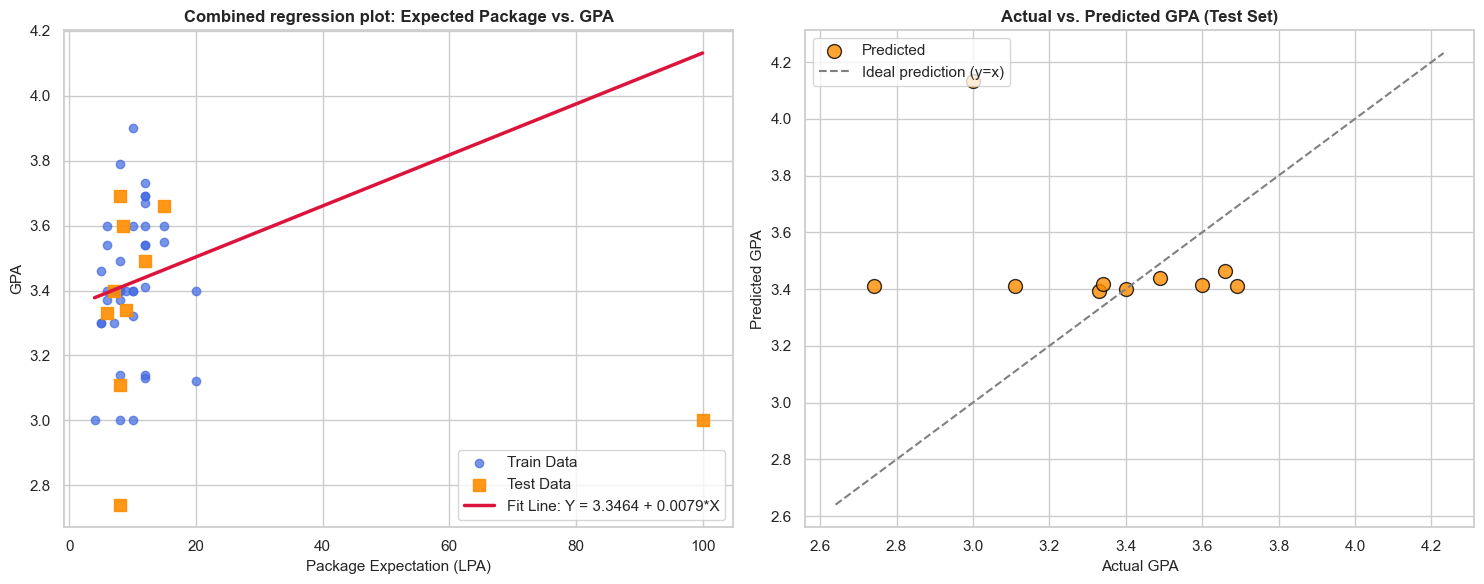

In [6]:
# 1. Save coefficients
params = {
    "intercept": float(b0_manual),
    "slope": float(b1_manual),
    "r2_train": float(r2_train),
    "r2_test": float(r2_test)
}
with open('model_params.json', 'w') as f:
    json.dump(params, f, indent=4)
print("Saved parameters to 'model_params.json'")

# 2. Plotting regression
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predictor vs Target (Fitted Line)
axes[0].scatter(X_train, y_train, color='royalblue', alpha=0.7, label='Train Data')
axes[0].scatter(X_test, y_test, color='darkorange', alpha=0.9, s=80, marker='s', label='Test Data')

x_line = np.linspace(df['package_exp'].min(), df['package_exp'].max(), 100)
y_line = b0_sklearn + b1_sklearn * x_line
axes[0].plot(x_line, y_line, color='crimson', linewidth=2.5, label=f'Fit Line: Y = {b0_sklearn:.4f} + {b1_sklearn:.4f}*X')
axes[0].set_title('Combined regression plot: Expected Package vs. GPA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Package Expectation (LPA)', fontsize=11)
axes[0].set_ylabel('GPA', fontsize=11)
axes[0].legend(loc='lower right')

# Plot 2: Actual vs Predicted GPA (Testing Set)
axes[1].scatter(y_test, y_pred_test, color='darkorange', s=100, edgecolors='black', alpha=0.8, label='Predicted')
ideal_min = min(y_test.min(), y_pred_test.min()) - 0.1
ideal_max = max(y_test.max(), y_pred_test.max()) + 0.1
axes[1].plot([ideal_min, ideal_max], [ideal_min, ideal_max], color='grey', linestyle='--', label='Ideal prediction (y=x)')
axes[1].set_title('Actual vs. Predicted GPA (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual GPA', fontsize=11)
axes[1].set_ylabel('Predicted GPA', fontsize=11)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('gpa_package_regression.png', dpi=300)
plt.show()

## Section 7: Data Analyst / Data Scientist Interpretations

### 1. Variables Selection (GPA as Y, Package Expectations as X)
- **Y (GPA)** is the academic response/target variable.
- **X (package_exp)** is the package expectation predictor.
- Conceptionally, a student's current academic performance (GPA) might serve as a foundation that enables them to demand a higher placement package. Thus, conceptually, GPA leads to package expectation. 
- However, for this regression task, we model GPA as a function of package expectations ($GPA = b_0 + b_1 \times package\_exp$). This lets us analyze if a student's high package confidence/career aspiration ($X$) exhibits a linear relationship with their academic performance ($Y$).

### 2. Slope Interpretation in Plain English
- The slope ($b_1 \approx 0.007857$) represents the change in GPA associated with a 1 LPA (Lakh Per Annum) increase in package expectations.
- **In plain English, for every 1 LPA increase in expected salary package, the student's GPA is estimated to increase by 0.0079 points.** This represents a negligible impact.

### 3. Model Reliability and R-squared ($R^2$)
- **$R^2$ Train**: $1.78\%$
- **$R^2$ Test**: $-134.16\%$
- The extremely low training $R^2$ indicates that expected package explains practically none of the variance in GPAs. 
- The negative test $R^2$ shows that predicting using the regression line is worse than simply guessing the mean GPA of the test set. **Therefore, package expectations have no linear predictive value for GPAs, and the model is not strong enough to trust.**